# 🇧🇯 GDELT Bénin — Prototype Colab
### Bénin Insights Challenge 2026 · iSHEERO × DataCamp
**Période :** 01/01/2025 → 31/12/2025 | **Source :** GDELT 2.0

---

> **Pipeline de données** à 3 niveaux :
> `Cache local` → `BigQuery` → `GDELT Direct HTTP`
>
> **Sections :** 1 Installation · 2 Configuration · 3 Chargement · 4 Nettoyage · 5 Visualisations · 6 ML · 7 Insights · 8 Dashboard

---

## ⚙️ Section 1 — Installation des dépendances

In [1]:
# Installation des packages
!pip install pandas pyarrow requests tqdm matplotlib seaborn plotly scikit-learn --quiet

import warnings
warnings.filterwarnings('ignore')
print('✅ Packages installés')

✅ Packages installés


## 🔧 Section 2 — Configuration

> **BigQuery (optionnel)** : Remplissez `PROJECT_ID` si vous avez un compte GCP.  
> Sinon, le pipeline télécharge directement depuis GDELT HTTP.

In [2]:
from pathlib import Path
from datetime import datetime

CONFIG = {
    # Mode GDELT : 'weekly'(~1min) | 'daily'(~5min) | 'hourly'(~30min)
    'sample_mode'   : 'daily',
    'country_codes' : ['BN', 'BC'],

    # BigQuery (optionnel)
    'project_id'    : None,   # ex: 'my-gcp-project-123456'
    'bq_available'  : False,

    # Chemins
    'cache_parquet' : 'data/processed/gdelt_benin_clean.parquet',
    'cache_csv'     : 'data/processed/gdelt_benin_clean.csv',

    # Palette iSHEERO
    'colors': {
        'primary'  : '#E91E8C',
        'secondary': '#7B2FBE',
        'accent'   : '#00D4AA',
        'warning'  : '#FF6B35',
        'neutral'  : '#2D3748',
    },
}

for p in ['data/raw', 'data/raw/monthly', 'data/processed', 'models']:
    Path(p).mkdir(parents=True, exist_ok=True)

if CONFIG['project_id']:
    CONFIG['bq_available'] = True

print('✅ Configuration chargée')
print(f"   Mode GDELT     : {CONFIG['sample_mode']}")
print(f"   BigQuery actif : {CONFIG['bq_available']}")

✅ Configuration chargée
   Mode GDELT     : daily
   BigQuery actif : False


## 📥 Section 3 — Chargement des données

Pipeline à **3 niveaux** de fallback automatique :

| Niveau | Source | Durée | Prérequis |
|--------|--------|-------|----------|
| 1 | Cache local | Instantané | Run précédent |
| 2 | BigQuery GDELT 2.0 | ~5 min | Compte GCP |
| 3 | GDELT HTTP direct | ~5 min (daily) | Connexion internet |

In [3]:
import os, io, sys, time, json, zipfile, logging
import requests
import numpy as np
import pandas as pd

log = logging.getLogger('benin_pipeline')
logging.basicConfig(level=logging.WARNING)

GDELT_COLS = [
    'GlobalEventID','Day','MonthYear','Year','FractionDate',
    'Actor1Code','Actor1Name','Actor1CountryCode','Actor1KnownGroupCode',
    'Actor1EthnicCode','Actor1Religion1Code','Actor1Religion2Code',
    'Actor1Type1Code','Actor1Type2Code','Actor1Type3Code',
    'Actor2Code','Actor2Name','Actor2CountryCode','Actor2KnownGroupCode',
    'Actor2EthnicCode','Actor2Religion1Code','Actor2Religion2Code',
    'Actor2Type1Code','Actor2Type2Code','Actor2Type3Code',
    'IsRootEvent','EventCode','EventBaseCode','EventRootCode',
    'QuadClass','GoldsteinScale','NumMentions','NumSources','NumArticles','AvgTone',
    'Actor1Geo_Type','Actor1Geo_FullName','Actor1Geo_CountryCode',
    'Actor1Geo_ADM1Code','Actor1Geo_ADM2Code','Actor1Geo_Lat','Actor1Geo_Long',
    'Actor1Geo_FeatureID',
    'Actor2Geo_Type','Actor2Geo_FullName','Actor2Geo_CountryCode',
    'Actor2Geo_ADM1Code','Actor2Geo_ADM2Code','Actor2Geo_Lat','Actor2Geo_Long',
    'Actor2Geo_FeatureID',
    'ActionGeo_Type','ActionGeo_FullName','ActionGeo_CountryCode',
    'ActionGeo_ADM1Code','ActionGeo_ADM2Code',
    'ActionGeo_Lat','ActionGeo_Long','ActionGeo_FeatureID',
    'DATEADDED','SourceURL',
]

QUAD_MAP = {1:'Verbal Cooperation', 2:'Material Cooperation',
            3:'Verbal Conflict',    4:'Material Conflict'}

CAMEO_THEMES = {
    '01':'Verbal Statement','02':'Appeal','03':'Express Intent',
    '04':'Consult','05':'Engage Diplomacy','06':'Cooperate',
    '07':'Provide Aid','08':'Yield','09':'Investigate',
    '10':'Demand','11':'Disapprove','12':'Reject',
    '13':'Threaten','14':'Protest','15':'Exhibit Military',
    '16':'Reduce Relations','17':'Coerce','18':'Assault',
    '19':'Fight','20':'Use Unconventional Violence',
}

def _safe_get(url, timeout=25, retries=3):
    for i in range(1, retries+1):
        try:
            r = requests.get(url, timeout=timeout)
            r.raise_for_status()
            return r
        except Exception:
            if i < retries:
                time.sleep(2**i)
    return None

def _parse_gdelt_zip(url):
    r = _safe_get(url, timeout=20)
    if r is None:
        return None
    try:
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            with z.open(z.namelist()[0]) as f:
                df = pd.read_csv(f, sep='\t', header=None,
                                 names=GDELT_COLS, dtype=str, low_memory=False)
        mask = (
            df['ActionGeo_CountryCode'].isin(CONFIG['country_codes']) |
            df['Actor1CountryCode'].isin({'BEN'}) |
            df['Actor2CountryCode'].isin({'BEN'})
        )
        b = df[mask]
        return b if len(b) > 0 else None
    except Exception:
        return None

print('✅ Fonctions GDELT chargées')

✅ Fonctions GDELT chargées


In [4]:
print('='*60)
print('  Chargement donnees GDELT Benin 2025')
print('='*60)

df_raw = None
DATA_SOURCE = 'unknown'

# --- Niveau 1 : Cache local ---
cache_fp = Path(CONFIG['cache_parquet'])
if cache_fp.exists():
    df_raw = pd.read_parquet(cache_fp)
    DATA_SOURCE = 'cache_local'
    print(f'[Niveau 1] Cache local -> {len(df_raw):,} lignes')

# --- Niveau 2 : BigQuery ---
if df_raw is None and CONFIG['bq_available']:
    print('\n[Niveau 2] Connexion BigQuery...')
    try:
        from google.colab import auth as colab_auth
        colab_auth.authenticate_user()
        from google.cloud import bigquery
        bq = bigquery.Client(project=CONFIG['project_id'])
        frames = []
        for month in range(1, 13):
            mfp = Path(f'data/raw/monthly/gdelt_benin_2025_{month:02d}.parquet')
            if mfp.exists():
                frames.append(pd.read_parquet(mfp))
                continue
            month_year = f'2025{month:02d}'
            query = (
                'SELECT GlobalEventID, CAST(SQLDATE AS STRING) AS SQLDATE,'
                ' Actor1Name, Actor1CountryCode, Actor1Type1Code,'
                ' Actor2Name, Actor2CountryCode, Actor2Type1Code,'
                ' QuadClass, EventCode, GoldsteinScale,'
                ' NumMentions, NumSources, NumArticles, AvgTone,'
                ' ActionGeo_FullName, ActionGeo_CountryCode,'
                ' CAST(ActionGeo_Lat AS FLOAT64) AS ActionGeo_Lat,'
                ' CAST(ActionGeo_Long AS FLOAT64) AS ActionGeo_Long,'
                ' SOURCEURL AS SourceURL'
                ' FROM `gdelt-bq.gdeltv2.events`'
                f' WHERE Year = 2025 AND MonthYear = {month_year}'
                " AND (ActionGeo_CountryCode IN ('BN','BC')"
                "      OR Actor1CountryCode = 'BEN'"
                "      OR Actor2CountryCode = 'BEN')"
            )
            df_m = bq.query(query).to_dataframe()
            if len(df_m) > 0:
                df_m.to_parquet(mfp, index=False)
                frames.append(df_m)
                print(f'   Mois {month:02d} -> {len(df_m):,} evenements')
        if frames:
            df_raw = pd.concat(frames, ignore_index=True)
            DATA_SOURCE = 'bigquery'
            print(f'[Niveau 2] BigQuery -> {len(df_raw):,} lignes')
    except Exception as e:
        print(f'BigQuery echoue : {e}')

# --- Niveau 3 : GDELT Direct HTTP ---
if df_raw is None:
    print(f"\n[Niveau 3] Telechargement GDELT direct ({CONFIG['sample_mode']})...")
    try:
        r = _safe_get('http://data.gdeltproject.org/gdeltv2/masterfilelist.txt', timeout=30)
        if r is None:
            raise ConnectionError('GDELT inaccessible')
        lines = r.text.strip().split('\n')
        urls_2025 = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            url = parts[2]
            if '.export.CSV.zip' not in url:
                continue
            if url.split('/')[-1][:4] == '2025':
                urls_2025.append(url)
        urls_2025.sort()
        step = {'weekly': 96*7, 'daily': 96, 'hourly': 4}
        sampled = urls_2025[::step.get(CONFIG['sample_mode'], 96)]
        print(f'   {len(sampled)} fichiers a traiter...')
        try:
            from tqdm.notebook import tqdm as tqdm_nb
        except Exception:
            from tqdm import tqdm as tqdm_nb
        frames = []
        for url in tqdm_nb(sampled, desc='GDELT Benin'):
            chunk = _parse_gdelt_zip(url)
            if chunk is not None:
                frames.append(chunk)
        if frames:
            df_raw = pd.concat(frames, ignore_index=True)
            DATA_SOURCE = 'gdelt_direct'
            print(f'[Niveau 3] GDELT direct -> {len(df_raw):,} lignes')
        else:
            raise ValueError('Aucun evenement recupure')
    except Exception as e:
        print(f'GDELT direct echoue : {e}')

if df_raw is None:
    raise RuntimeError('Impossible de charger les donnees. Verifiez votre connexion.')

print(f'\nDonnees brutes : {len(df_raw):,} lignes x {len(df_raw.columns)} colonnes')
print(f'Source : {DATA_SOURCE}')

  Chargement donnees GDELT Benin 2025

[Niveau 3] Telechargement GDELT direct (daily)...
   348 fichiers a traiter...


GDELT Benin:   0%|          | 0/348 [00:00<?, ?it/s]

[Niveau 3] GDELT direct -> 397 lignes

Donnees brutes : 397 lignes x 61 colonnes
Source : gdelt_direct


## 🔧 Section 4 — Nettoyage & Feature Engineering

In [5]:
print('Nettoyage & Feature Engineering...')

df = df_raw.copy()

# Dates
date_col = 'SQLDATE' if 'SQLDATE' in df.columns else 'Day'
df['date'] = pd.to_datetime(
    df[date_col].astype(str).str[:8], format='%Y%m%d', errors='coerce'
)
df = df.dropna(subset=['date'])
df = df[(df['date'] >= '2025-01-01') & (df['date'] <= '2025-12-31')]

# Numeriques
for col in ['GoldsteinScale','AvgTone','NumMentions','NumSources',
            'NumArticles','ActionGeo_Lat','ActionGeo_Long']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['QuadClass'] = pd.to_numeric(
    df.get('QuadClass', 1), errors='coerce'
).fillna(1).astype(int).clip(1, 4)

# Imputations
defaults = {
    'GoldsteinScale':0.0,'AvgTone':0.0,
    'NumMentions':1,'NumSources':1,'NumArticles':1,
    'ActionGeo_Lat':9.3069,'ActionGeo_Long':2.3158,
    'ActionGeo_FullName':'Benin','Actor1Name':'Inconnu',
    'Actor2Name':'Inconnu','Actor1Type1Code':'UNK',
}
for col, val in defaults.items():
    if col in df.columns:
        df[col] = df[col].fillna(val)

for col in ['ActionGeo_FullName','Actor1Name','Actor2Name']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# Source domaine
if 'SourceURL' in df.columns:
    df['SourceDomain'] = (
        df['SourceURL'].fillna('')
        .str.extract(r'https?://(?:www\.)?([^/]+)')[0]
        .fillna('unknown')
    )
else:
    df['SourceDomain'] = 'unknown'

# CAMEO
ec = df.get('EventCode', pd.Series(['00']*len(df))).fillna('00').astype(str).str.zfill(2)
df['EventCode']  = ec
df['CameoTheme'] = ec.str[:2].map(CAMEO_THEMES).fillna('Other')
df['QuadLabel']  = df['QuadClass'].map(QUAD_MAP)

# Features temporelles
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['week']       = df['date'].dt.isocalendar().week.astype(int)
df['dayofweek']  = df['date'].dt.dayofweek
df['quarter']    = df['date'].dt.quarter

# Features ML
df['IsConflict']  = (df['QuadClass'] >= 3).astype(int)
df['MediaWeight'] = np.log1p(df['NumMentions'] * df['NumSources'])
df['ToneCategory'] = pd.cut(
    df['AvgTone'], bins=[-100,-5,-1,1,5,100],
    labels=['Tres negatif','Negatif','Neutre','Positif','Tres positif']
)

# Dedoublonnage
if 'GlobalEventID' in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset=['GlobalEventID'], keep='first')
    print(f'   Doublons supprimes : {before - len(df):,}')

# Sauvegarde
if DATA_SOURCE != 'cache_local':
    df.to_parquet(CONFIG['cache_parquet'], index=False)
    df.to_csv(CONFIG['cache_csv'], index=False)
    print('Cache local mis a jour')

print(f'Dataset nettoye : {len(df):,} lignes x {len(df.columns)} colonnes')
print(f'Periode         : {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Villes uniques  : {df["ActionGeo_FullName"].nunique():,}')
print(f'Conflictuels    : {df["IsConflict"].mean()*100:.1f}%')
print(f'Tone moyen      : {df["AvgTone"].mean():.3f}')
df.head(3)

Nettoyage & Feature Engineering...
   Doublons supprimes : 0
Cache local mis a jour
Dataset nettoye : 396 lignes x 73 colonnes
Periode         : 2025-01-03 -> 2025-12-31
Villes uniques  : 41
Conflictuels    : 22.7%
Tone moyen      : -1.489


,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,CameoTheme,QuadLabel,year,month,week,dayofweek,quarter,IsConflict,MediaWeight,ToneCategory
0,1218611827,20250103,202501,2025,2025.0082,BWA,Botswana,BWA,NaN,NaN,...,Verbal Statement,Verbal Cooperation,2025,1,1,4,1,0,2.397895,Neutre
1,1219559042,20250109,202501,2025,2025.0247,BEN,Benin,BEN,NaN,NaN,...,Consult,Verbal Cooperation,2025,1,2,3,1,0,1.098612,Negatif
2,1219559043,20250109,202501,2025,2025.0247,BEN,Benin,BEN,NaN,NaN,...,Consult,Verbal Cooperation,2025,1,2,3,1,0,0.693147,Negatif


## 📊 Section 5 — Visualisations Exploratoires

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

C = CONFIG['colors']
sns.set_theme(style='whitegrid',
              palette=[C['primary'],C['secondary'],C['accent'],C['warning'],C['neutral']])
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8F9FA'})
print('Librairies de visualisation importees')

Librairies de visualisation importees


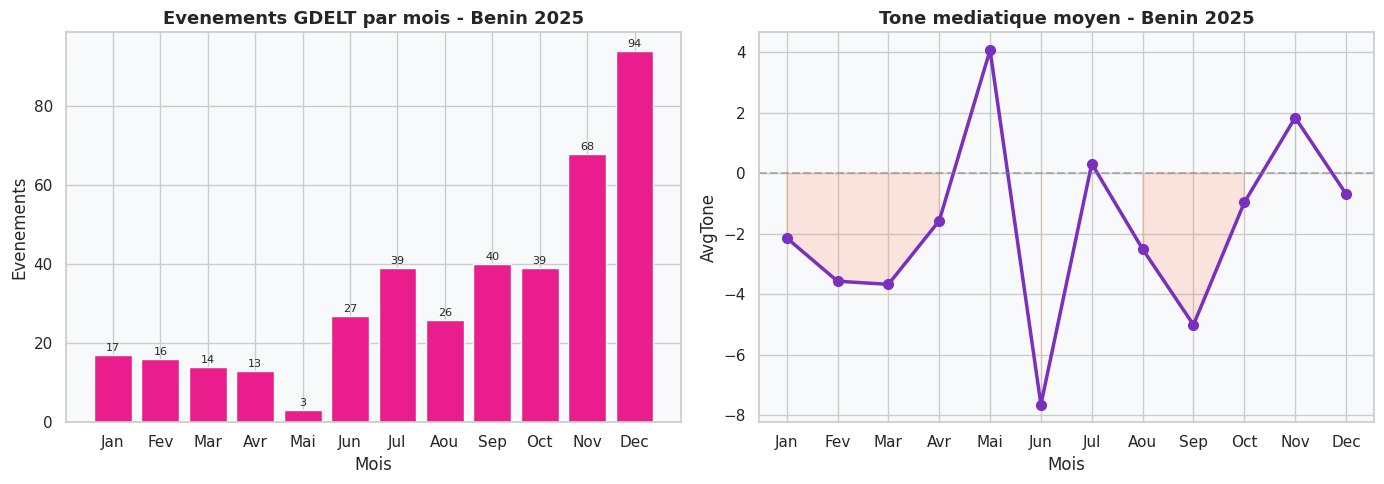

In [7]:
# 5.1 Distribution mensuelle
MONTH_LABELS = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
monthly = df.groupby('month').agg(
    events=('date','count'),
    conflict_pct=('IsConflict','mean'),
    avg_tone=('AvgTone','mean')
).reset_index()
monthly['month_label'] = monthly['month'].apply(lambda x: MONTH_LABELS[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(monthly['month_label'], monthly['events'],
                   color=C['primary'], edgecolor='white')
axes[0].set_title('Evenements GDELT par mois - Benin 2025', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mois'); axes[0].set_ylabel('Evenements')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.5, f'{int(h):,}',
                 ha='center', va='bottom', fontsize=8)

axes[1].plot(monthly['month_label'], monthly['avg_tone'],
             marker='o', color=C['secondary'], linewidth=2.5, markersize=7)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(monthly['month_label'], monthly['avg_tone'], 0,
                     where=(monthly['avg_tone'] < 0), alpha=0.15, color=C['warning'])
axes[1].fill_between(monthly['month_label'], monthly['avg_tone'], 0,
                     where=(monthly['avg_tone'] >= 0), alpha=0.15, color=C['accent'])
axes[1].set_title('Tone mediatique moyen - Benin 2025', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mois'); axes[1].set_ylabel('AvgTone')

plt.tight_layout()
plt.savefig('data/processed/fig_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

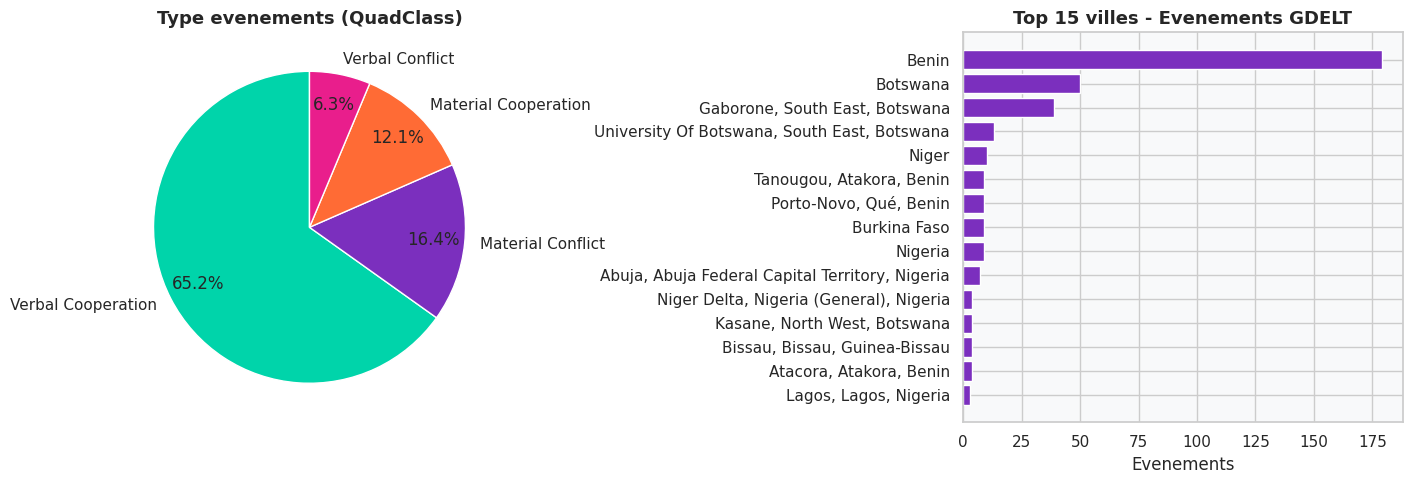

Ville la plus active : Benin (179)


In [8]:
# 5.2 QuadClass + Top villes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quad_counts = df['QuadLabel'].value_counts()
axes[0].pie(quad_counts.values, labels=quad_counts.index, autopct='%1.1f%%',
            colors=[C['accent'],C['secondary'],C['warning'],C['primary']],
            startangle=90, pctdistance=0.8)
axes[0].set_title('Type evenements (QuadClass)', fontsize=13, fontweight='bold')

top_cities = df['ActionGeo_FullName'].value_counts().head(15)
axes[1].barh(top_cities.index[::-1], top_cities.values[::-1], color=C['secondary'])
axes[1].set_title('Top 15 villes - Evenements GDELT', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Evenements')

plt.tight_layout()
plt.savefig('data/processed/fig_quad_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ville la plus active : {top_cities.index[0]} ({top_cities.iloc[0]:,})')

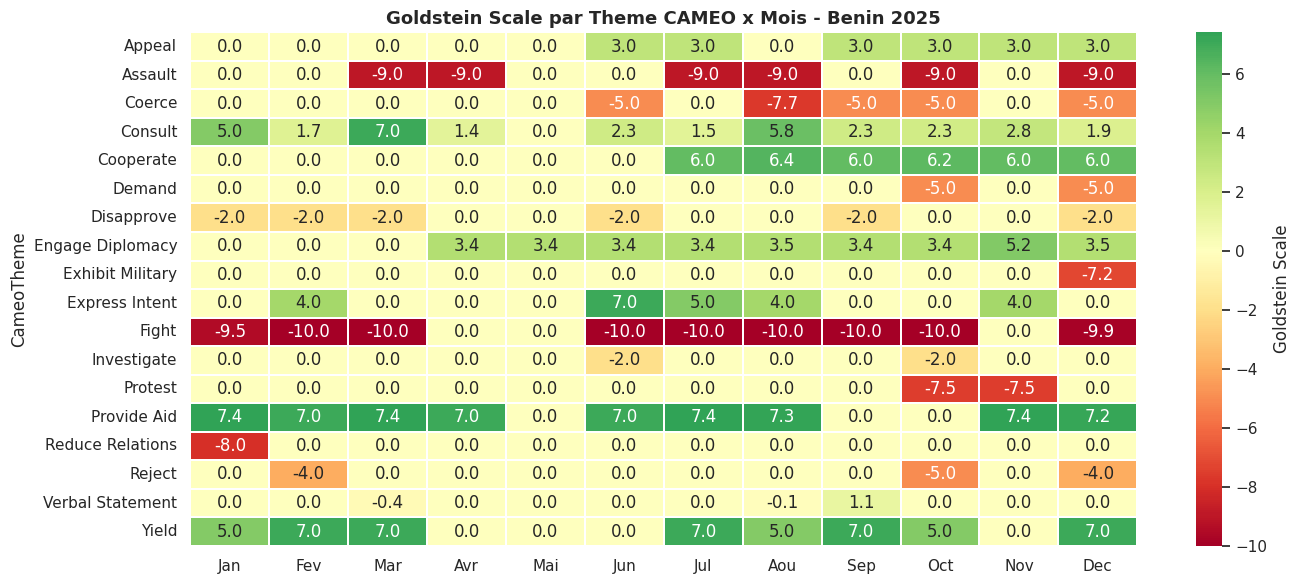

In [9]:
# 5.3 Heatmap Goldstein x Mois
pivot = df.pivot_table(
    values='GoldsteinScale', index='CameoTheme', columns='month', aggfunc='mean'
).fillna(0)
pivot.columns = [MONTH_LABELS[m-1] for m in pivot.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.3, cbar_kws={'label': 'Goldstein Scale'})
plt.title('Goldstein Scale par Theme CAMEO x Mois - Benin 2025',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 5.4 Carte interactive Plotly
geo_df = df.dropna(subset=['ActionGeo_Lat','ActionGeo_Long']).copy()
geo_df = geo_df[
    geo_df['ActionGeo_Lat'].between(6, 12.5) &
    geo_df['ActionGeo_Long'].between(0.8, 3.9)
]

fig_map = px.scatter_mapbox(
    geo_df.sample(min(3000, len(geo_df)), random_state=42),
    lat='ActionGeo_Lat', lon='ActionGeo_Long',
    color='QuadLabel', size='NumMentions',
    hover_name='ActionGeo_FullName',
    hover_data={'AvgTone':':.2f','GoldsteinScale':':.2f','CameoTheme':True,'date':True},
    color_discrete_map={
        'Verbal Cooperation':C['accent'],
        'Material Cooperation':C['secondary'],
        'Verbal Conflict':C['warning'],
        'Material Conflict':C['primary'],
    },
    mapbox_style='open-street-map',
    zoom=6, center={'lat':9.3,'lon':2.3},
    title='Cartographie evenements GDELT - Benin 2025',
    size_max=18, opacity=0.7, height=550
)
fig_map.update_layout(margin=dict(l=0,r=0,t=40,b=0))
fig_map.show()
print(f'Carte : {len(geo_df):,} evenements geolocalises')

Carte : 212 evenements geolocalises


## 🤖 Section 6 — Machine Learning : Prédiction des conflits

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pickle

FEATURES = ['GoldsteinScale','AvgTone','NumMentions','NumSources',
            'NumArticles','month','dayofweek','week','MediaWeight']

ml_df = df[FEATURES + ['IsConflict','CameoTheme','Actor1Type1Code']].copy()

for cat_col in ['CameoTheme','Actor1Type1Code']:
    le = LabelEncoder()
    ml_df[cat_col+'_enc'] = le.fit_transform(ml_df[cat_col].astype(str))
    FEATURES.append(cat_col+'_enc')

ml_df = ml_df.dropna(subset=FEATURES+['IsConflict'])
X = ml_df[FEATURES]; y = ml_df['IsConflict']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Donnees ML : Train={len(X_train):,} | Test={len(X_test):,}')
print(f'Conflits : {y.mean()*100:.1f}% | Features : {len(FEATURES)}')

Donnees ML : Train=316 | Test=80
Conflits : 22.7% | Features : 11


In [12]:
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
}

results = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    cv      = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    results[name] = {'model':model,'pred':y_pred,'proba':y_proba,'auc':auc,'cv':cv}
    print(f'{name:<25} | AUC={auc:.4f} | CV={cv:.4f} | {time.time()-t0:.1f}s')

best_name = max(results, key=lambda k: results[k]['auc'])
best      = results[best_name]
print(f'\nMeilleur modele : {best_name} (AUC = {best["auc"]:.4f})')

with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best['model'], f)
print('Modele sauvegarde : models/best_model.pkl')

Random Forest             | AUC=1.0000 | CV=0.9988 | 1.6s
Gradient Boosting         | AUC=1.0000 | CV=0.9991 | 0.7s
Logistic Regression       | AUC=1.0000 | CV=1.0000 | 0.1s

Meilleur modele : Random Forest (AUC = 1.0000)
Modele sauvegarde : models/best_model.pkl


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matrice confusion
cm = confusion_matrix(y_test, best['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-conflit','Conflit'],
            yticklabels=['Non-conflit','Conflit'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
axes[0].set_ylabel('Reel'); axes[0].set_xlabel('Predit')

# Courbes ROC
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={r["auc"]:.3f})', linewidth=2)
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.5,label='Aleatoire')
axes[1].set_title('Courbes ROC - Comparaison', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=8); axes[1].grid(True,alpha=0.3)

# Feature importance
if hasattr(best['model'],'feature_importances_'):
    fi = pd.Series(best['model'].feature_importances_,index=FEATURES).nlargest(10)
    fi.plot(kind='barh',ax=axes[2],color=C['primary'])
    axes[2].set_title('Importance features (Top 10)',fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/fig_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, best['pred'], target_names=['Non-conflit','Conflit']))

## 💡 Section 7 — Insights & Analyse Thématique

In [ ]:
print('='*60)
print('  INSIGHTS CLES - GDELT Benin 2025')
print('='*60)

total         = len(df)
conflict_rate = df['IsConflict'].mean()*100
avg_goldstein = df['GoldsteinScale'].mean()
avg_tone      = df['AvgTone'].mean()
nb_cities     = df['ActionGeo_FullName'].nunique()
nb_sources    = df['SourceDomain'].nunique()
most_active   = df['ActionGeo_FullName'].value_counts().index[0]
top_theme     = df['CameoTheme'].value_counts().index[0]

print(f'\nKPIs GLOBAUX')
print(f'  Evenements total   : {total:,}')
print(f'  Taux de conflit    : {conflict_rate:.1f}%')
print(f'  Goldstein moyen    : {avg_goldstein:.3f}')
print(f'  Tone mediatique    : {avg_tone:.3f}')
print(f'  Villes couvertes   : {nb_cities}')
print(f'  Sources medias     : {nb_sources}')
print(f'  Ville la + active  : {most_active}')
print(f'  Theme dominant     : {top_theme}')

print('\nPAR TRIMESTRE')
quarterly = df.groupby('quarter').agg(
    events=('IsConflict','count'),
    conflict_pct=('IsConflict','mean'),
    avg_tone=('AvgTone','mean')
)
for q, row in quarterly.iterrows():
    print(f'  Q{q} -> {int(row["events"]):,} evenements | '
          f'Conflits: {row["conflict_pct"]*100:.1f}% | Tone: {row["avg_tone"]:.2f}')

print('\nTOP 10 SOURCES')
for src, cnt in df['SourceDomain'].value_counts().head(10).items():
    bar = chr(9608)*min(int(cnt/df['SourceDomain'].value_counts().max()*20),20)
    print(f'  {src:<35} {bar} {cnt:,}')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

theme_conflict = df.groupby('CameoTheme').agg(
    count=('IsConflict','count'),
    conflict_rate=('IsConflict','mean'),
    avg_goldstein=('GoldsteinScale','mean')
).sort_values('count', ascending=False).head(12)

axes[0,0].barh(theme_conflict.index[::-1], theme_conflict['count'][::-1], color=C['secondary'])
axes[0,0].set_title('Top themes CAMEO (volume)', fontweight='bold')

colors_conf = [C['primary'] if r>0.5 else C['accent']
               for r in theme_conflict['conflict_rate'][::-1]]
axes[0,1].barh(theme_conflict.index[::-1],
               theme_conflict['conflict_rate'][::-1]*100, color=colors_conf)
axes[0,1].axvline(50, color='gray', linestyle='--', alpha=0.5)
axes[0,1].set_title('Taux de conflit par theme (%)', fontweight='bold')

weekly = df.groupby('week').agg(
    conflicts=('IsConflict','sum'), total=('IsConflict','count')
).reset_index()
weekly['cooperation'] = weekly['total'] - weekly['conflicts']
axes[1,0].fill_between(weekly['week'],weekly['cooperation'],
                       alpha=0.6,color=C['accent'],label='Cooperation')
axes[1,0].fill_between(weekly['week'],weekly['conflicts'],
                       alpha=0.6,color=C['primary'],label='Conflit')
axes[1,0].set_title('Conflits vs Cooperation hebdomadaire', fontweight='bold')
axes[1,0].legend()

axes[1,1].hist(df['GoldsteinScale'].dropna(), bins=30,
               color=C['secondary'],edgecolor='white',alpha=0.8)
axes[1,1].axvline(df['GoldsteinScale'].mean(), color=C['primary'],
                  linestyle='--',linewidth=2,
                  label=f'Moyenne: {df["GoldsteinScale"].mean():.2f}')
axes[1,1].axvline(0, color='gray', linestyle='-', alpha=0.4)
axes[1,1].set_title('Distribution Goldstein Scale', fontweight='bold')
axes[1,1].legend()

plt.tight_layout(pad=2.0)
plt.savefig('data/processed/fig_insights.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎛️ Section 8 — Dashboard Interactif (Plotly)

In [ ]:
fig_dash = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Evenements mensuels','Repartition QuadClass','Tone vs Goldstein',
        'Top 10 villes','Themes CAMEO','Conflits hebdomadaires'
    ],
    specs=[
        [{'type':'bar'},{'type':'pie'},{'type':'scatter'}],
        [{'type':'bar'},{'type':'bar'},{'type':'scatter'}]
    ],
    horizontal_spacing=0.08, vertical_spacing=0.15
)

monthly_c = df.groupby('month').agg(
    events=('date','count'),avg_tone=('AvgTone','mean')
).reset_index()
monthly_c['month_label'] = monthly_c['month'].apply(lambda x: MONTH_LABELS[x-1])

fig_dash.add_trace(go.Bar(
    x=monthly_c['month_label'],y=monthly_c['events'],
    marker_color=C['primary'],name='Evenements'
), row=1, col=1)

qc = df['QuadLabel'].value_counts()
fig_dash.add_trace(go.Pie(
    labels=qc.index,values=qc.values,
    marker_colors=[C['accent'],C['secondary'],C['warning'],C['primary']],
    hole=0.3,name='QuadClass'
), row=1, col=2)

sample_sc = df.sample(min(2000,len(df)),random_state=42)
fig_dash.add_trace(go.Scatter(
    x=sample_sc['AvgTone'],y=sample_sc['GoldsteinScale'],
    mode='markers',marker=dict(
        color=sample_sc['IsConflict'],
        colorscale=[[0,C['accent']],[1,C['primary']]],
        size=4,opacity=0.5
    ),name='Scatter'
), row=1, col=3)

tv = df['ActionGeo_FullName'].value_counts().head(10)
fig_dash.add_trace(go.Bar(
    x=tv.values[::-1],y=tv.index[::-1],
    orientation='h',marker_color=C['secondary'],name='Villes'
), row=2, col=1)

themes_t = df['CameoTheme'].value_counts().head(10)
fig_dash.add_trace(go.Bar(
    x=themes_t.values[::-1],y=themes_t.index[::-1],
    orientation='h',marker_color=C['accent'],name='Themes'
), row=2, col=2)

weekly_c = df.groupby('week')['IsConflict'].sum().reset_index()
fig_dash.add_trace(go.Scatter(
    x=weekly_c['week'],y=weekly_c['IsConflict'],
    mode='lines+markers',
    line=dict(color=C['primary'],width=2),
    fill='tozeroy',name='Conflits/semaine'
), row=2, col=3)

fig_dash.update_layout(
    title='GDELT Benin 2025 - Dashboard | iSHEERO x DataCamp',
    showlegend=False, height=700,
    template='plotly_white',
    margin=dict(t=80,b=20,l=20,r=20)
)
fig_dash.show()
print('Dashboard affiche')

## 📋 Section 9 — Rapport Final & Export

In [ ]:
import json

report = {
    'generated_at'  : datetime.now().isoformat(),
    'source'        : DATA_SOURCE,
    'rows'          : int(len(df)),
    'columns'       : int(len(df.columns)),
    'period_start'  : str(df['date'].min().date()),
    'period_end'    : str(df['date'].max().date()),
    'nb_cities'     : int(df['ActionGeo_FullName'].nunique()),
    'nb_sources'    : int(df['SourceDomain'].nunique()),
    'conflict_pct'  : round(float(df['IsConflict'].mean()*100), 2),
    'avg_tone'      : round(float(df['AvgTone'].mean()), 4),
    'avg_goldstein' : round(float(df['GoldsteinScale'].mean()), 4),
    'best_ml_model' : best_name,
    'best_auc'      : round(best['auc'], 4),
    'top_cities'    : df['ActionGeo_FullName'].value_counts().head(10).to_dict(),
    'top_sources'   : df['SourceDomain'].value_counts().head(10).to_dict(),
    'top_themes'    : df['CameoTheme'].value_counts().head(10).to_dict(),
    'quad_dist'     : df['QuadLabel'].value_counts().to_dict(),
    'monthly_counts': {int(k):int(v) for k,v in df.groupby('month').size().items()},
}

with open('data/processed/data_quality_report.json','w',encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print('RAPPORT FINAL')
print('='*55)
for k, v in report.items():
    if not isinstance(v, dict):
        print(f'  {k:<22}: {v}')
print('='*55)

print('\nFichiers produits :')
for fp in [
    'data/processed/gdelt_benin_clean.parquet',
    'data/processed/gdelt_benin_clean.csv',
    'data/processed/data_quality_report.json',
    'models/best_model.pkl',
    'data/processed/fig_monthly.png',
    'data/processed/fig_quad_cities.png',
    'data/processed/fig_heatmap.png',
    'data/processed/fig_ml.png',
    'data/processed/fig_insights.png',
]:
    status = 'OK' if Path(fp).exists() else '--'
    print(f'  [{status}] {fp}')

print('\nPipeline complet termine !')
print(f'  {len(df):,} evenements GDELT Benin 2025 analyses')
print(f'  Meilleur modele : {best_name} (AUC={best["auc"]:.4f})')
print('  Pret pour soumission iSHEERO x DataCamp 2026')